In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gsw
import xarray as xr
import utils
import os
from scipy.spatial import Delaunay
import time as tm
from scipy.sparse import *
from scipy.ndimage.filters import gaussian_filter
from scipy.sparse.linalg import spsolve


/tmp/ipykernel_32022/552487479.py:10: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


### Parameters to change

In [2]:
path_root='/data/hpcflash/users/josnez/Oceananigans/ICE-EDDY_wJ/V0/'
run_name='C-9-noise10percent_only_salt_BiH/'

path_save=path_root+'init_cond/'+run_name
try:
    os.mkdir(path_save)
except:
    pass

# Define dimensions of grid.

Lx,Ly=200e3,200e3 #good for eddy size R=10e3

dx=500 #in meters #LR : 2e3
dy=500
ngrid_z = 100

ngrid_x = int(Lx/dx)
ngrid_y = int(Ly/dy)


#Dimensions of box channel
Lx=ngrid_x*dx
Ly=ngrid_y*dy
Lz=4000#m

print(ngrid_x,ngrid_y)

# Array of dims of simulation
# Center points
x=np.linspace(dx/2, Lx-dx/2, ngrid_x)
y=np.linspace(dy/2, Ly-dy/2, ngrid_y)

# Edge grid
xu=np.linspace(0, Lx, ngrid_x + 1)
yv=np.linspace(0, Ly, ngrid_y + 1)

# xx,yy=np.meshgrid(x, y)

#Build initial conditions in edge conditions and then before storing interpolate to the center grid
xx,yy=np.meshgrid(xu, yv)


400 400


# Vortex initialization

### Change parameters in the cell below for exploring parameter space: 

To match high latitude (Radius & F_0), but mostly the rossby number. 

In [3]:
#Vortex parameters

posx_eddy = Lx/2.
posy_eddy = Ly/2.
posz_eddy = 0


power_shape          = 20 #2 is gaussian # larger for steep profiles
## Experiments R_N   = 0.3, 0.2, 0.1


lat=80

def coriolis_frequency(latitude_degrees):
    import math
    omega = 7.2921e-5  # Earth's angular velocity (rad/s)
    phi_rad = math.radians(latitude_degrees)
    f0 = 2 * omega * math.sin(phi_rad)
    return f0

f0=coriolis_frequency(lat);print(f0)

window='yes' #if we apply a window to avoid velocity at the edge of the domain
#it's safer for simulations to say yes, but the velocity profile is then not analytical

0.00014362633231480645


## Depth definition:

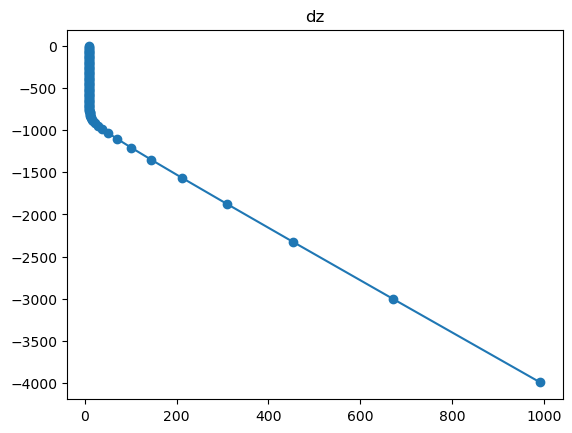

In [4]:
refinement = 4 # controls spacing near surface (higher means finer spaced)
stretching = 40  # controls rate of stretching at bottom

k=np.arange(1,ngrid_z+1)
# Normalized height ranging from 0 to 1
h = (k - 1) / ngrid_z

# Linear near-surface generator
eta = 1 + (h - 1) / refinement

# Bottom-intensified stretching function
Σ = (1 - np.exp(-stretching * h) / (1 - np.exp(-stretching)))

# Generating function
z_faces = Lz * (eta * Σ - 1)

#Flip for consistency with python code
z_faces = np.flipud(-z_faces)

depth = z_faces

plt.title('dz')
plt.plot(np.diff(z_faces),-np.cumsum(np.diff(z_faces)),'o-')
plt.show()

# Background profiles

In [5]:
# Create salt and temperature profiles.
depth_salt_var = -np.tanh( ((z_faces)/ 1700 ) * 2*np.pi ) +1 ;

def normalize(data):
    shift = data + abs(data.min())
    return shift/shift.max()

tanh_profile = normalize( np.tanh( (( z_faces - 150 )/ 2500 ) * 2*np.pi )) - 0.3  * 3 * np.tanh((z_faces-150)/3000) 

depth_temp_var = tanh_profile

S = 34.85
ΔS = 0.7 #ups 

init_sal_s = S - ΔS * depth_salt_var

ft_s= gsw.t_freezing(init_sal_s[0] ,0,0)

ΔT = 3
T0 = 0.8

init_temp_s = T0 + ft_s + ΔT * depth_temp_var #*np.ones_like(init_sal_s)

init_rho_s = gsw.rho(init_sal_s,init_temp_s,gsw.p_from_z(-np.array(z_faces),lat))
rho0=np.nanmean(init_rho_s)


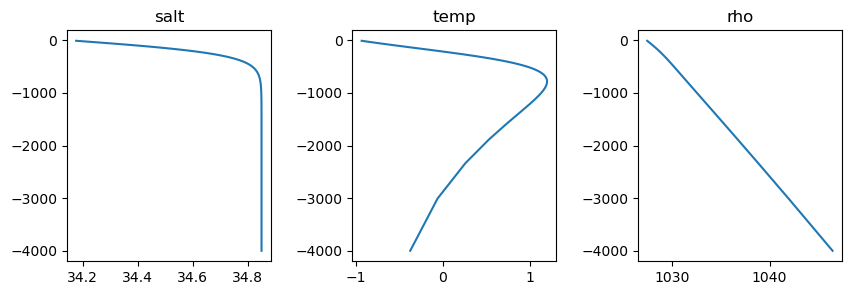

In [6]:
fig, ax = plt.subplots(1,3,figsize=(10,3))
ax[0].plot(init_sal_s,-z_faces)
ax[0].set_title('salt')
ax[1].plot(init_temp_s,-z_faces)
ax[1].set_title('temp')
ax[2].plot(init_rho_s,-z_faces)
ax[2].set_title('rho')
plt.subplots_adjust(wspace=0.4)
plt.show()

# $N^2$ 
The vertical stratification is defined as:
$$
N^2 = \frac{g}{\rho_0}\frac{\partial \rho}{\partial z} 
$$
and the rossby radius of deformation is:
$$
R_D = \frac{1}{m\pi f}\int_{-H}^0 N dz
$$

In [7]:
dz = np.diff(depth)
drho = np.diff(init_rho_s)/dz
g=9.81
rho0 = 1030
f = 0.000143

N = np.sqrt(g/rho0 * drho)

In [8]:
RD = 1/(np.pi* f) * np.sum( N * dz )

In [12]:
# 2*np.pi*RD

In [11]:
RD

np.float64(59904.44561426592)